
######################################################################
  DATASET: Iris  |  Shape: (150, 4)  |  True clusters: 3
######################################################################

  METRICS SUMMARY  -  Iris Dataset
Algorithm              Silhouette   DB-Index     CH-Index      ARI      NMI
----------------------------------------------------------------------
K-Means                    0.4599     0.8336       241.90   0.6201   0.6595  (k=3)
Agglomerative              0.4467     0.8035       222.72   0.6153   0.6755  (k=3)
DBSCAN                     0.6559     0.4942       343.97   0.4421   0.5114  (k=2)
Mean Shift                 0.4325     0.8131       163.71   0.5600   0.7036  (k=3)
GMM                        0.4751     0.8867       141.23   0.5165   0.6571  (k=3)
  Lower Davies-Bouldin is better.
  Higher Silhouette, CH-Index, ARI, NMI are better.



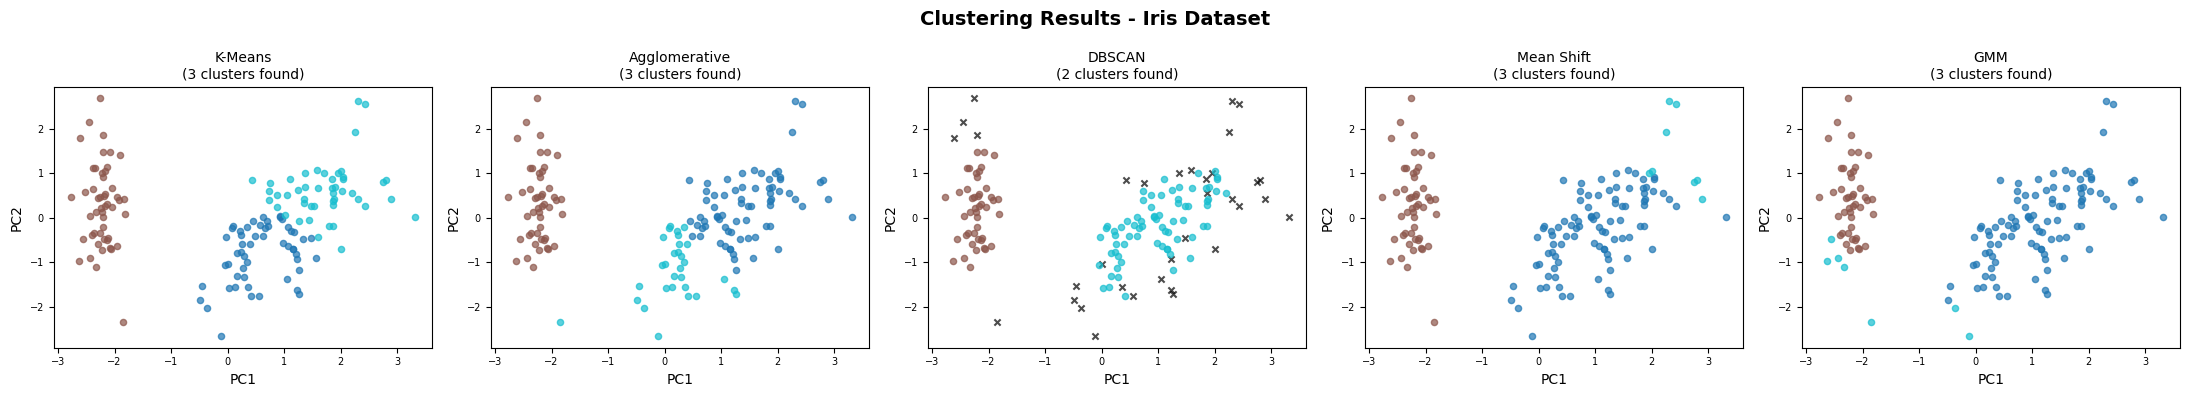

  Saved: clustering_iris.png


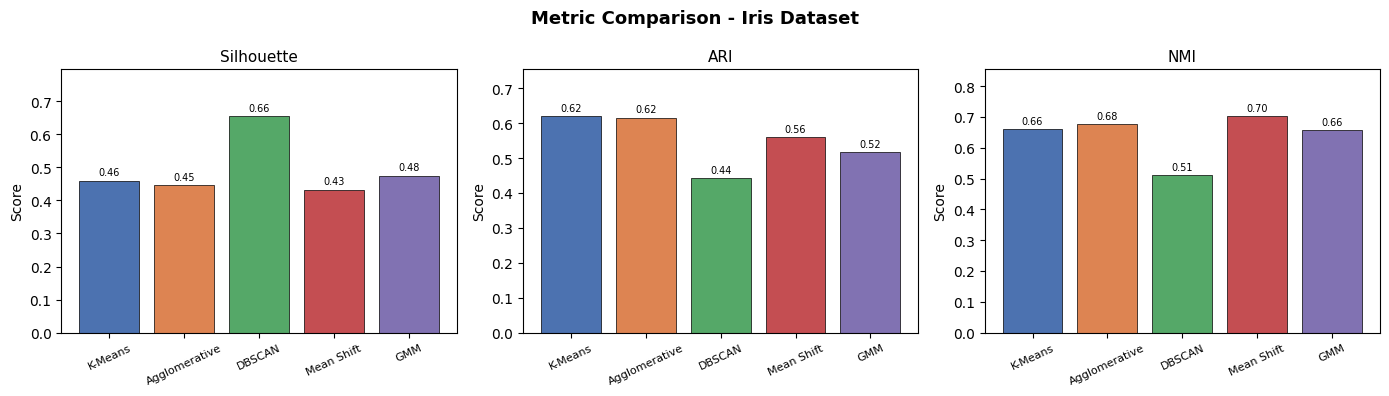

  Saved: metrics_iris.png

######################################################################
  DATASET: Wine  |  Shape: (178, 13)  |  True clusters: 3
######################################################################

  METRICS SUMMARY  -  Wine Dataset
Algorithm              Silhouette   DB-Index     CH-Index      ARI      NMI
----------------------------------------------------------------------
K-Means                    0.2849     1.3892        70.94   0.8975   0.8759  (k=3)
Agglomerative              0.2774     1.4186        67.65   0.7899   0.7865  (k=3)
DBSCAN                      N/A        N/A          N/A     0.0000   0.0000  (k=0)
Mean Shift                 0.2207     0.9828        18.91   0.3546   0.4520  (k=6)
GMM                        0.2849     1.3892        70.94   0.8975   0.8759  (k=3)
  Lower Davies-Bouldin is better.
  Higher Silhouette, CH-Index, ARI, NMI are better.



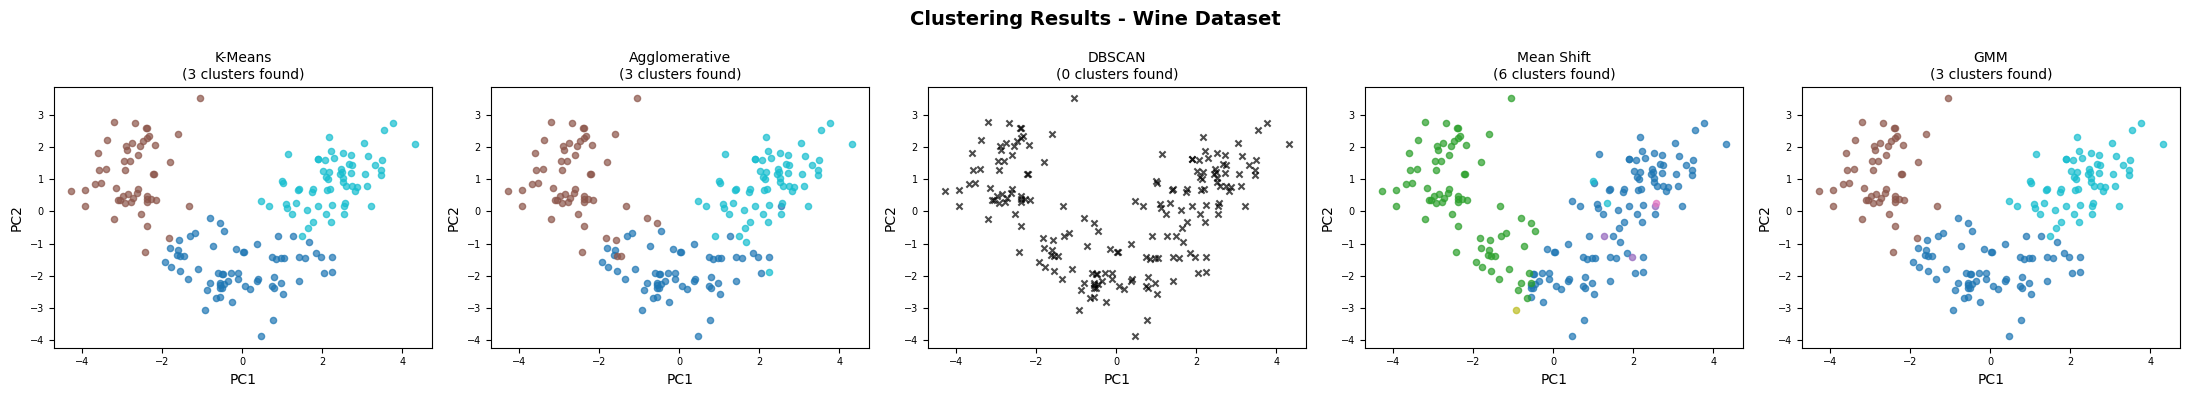

  Saved: clustering_wine.png


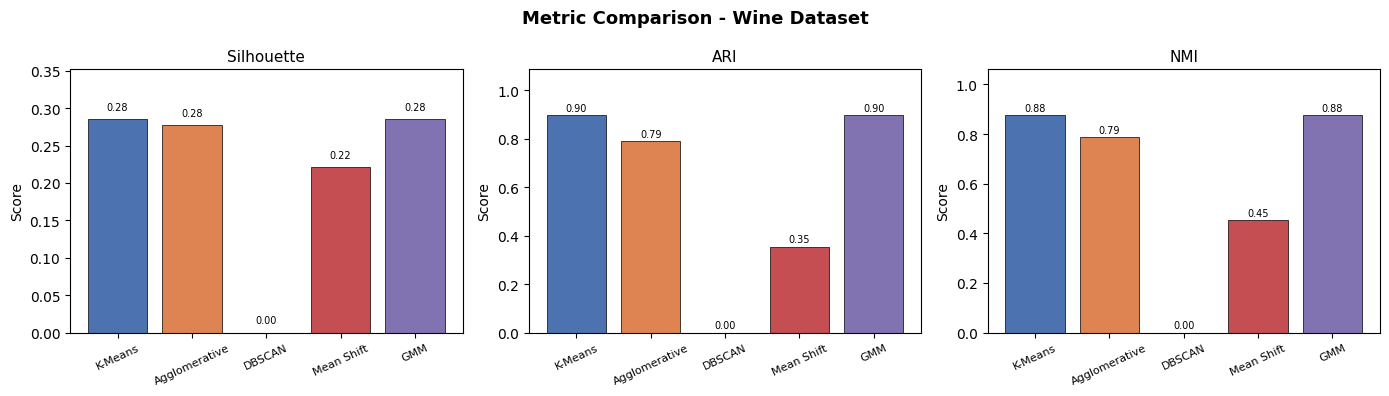

  Saved: metrics_wine.png

######################################################################
  DATASET: Blobs  |  Shape: (300, 2)  |  True clusters: 4
######################################################################

  METRICS SUMMARY  -  Blobs Dataset
Algorithm              Silhouette   DB-Index     CH-Index      ARI      NMI
----------------------------------------------------------------------
K-Means                    0.8386     0.2244      5132.39   1.0000   1.0000  (k=4)
Agglomerative              0.8386     0.2244      5132.39   1.0000   1.0000  (k=4)
DBSCAN                     0.7642     0.3490      1187.24   0.7122   0.8571  (k=3)
Mean Shift                 0.8386     0.2244      5132.39   1.0000   1.0000  (k=4)
GMM                        0.8386     0.2244      5132.39   1.0000   1.0000  (k=4)
  Lower Davies-Bouldin is better.
  Higher Silhouette, CH-Index, ARI, NMI are better.



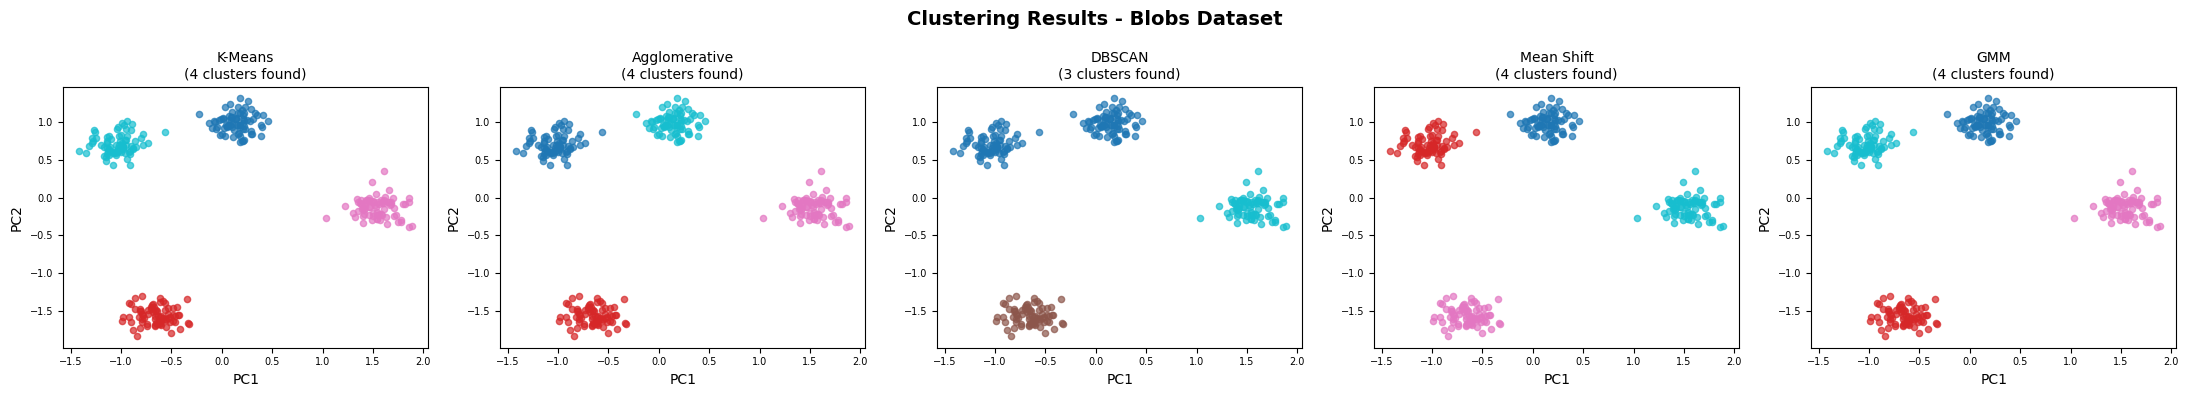

  Saved: clustering_blobs.png


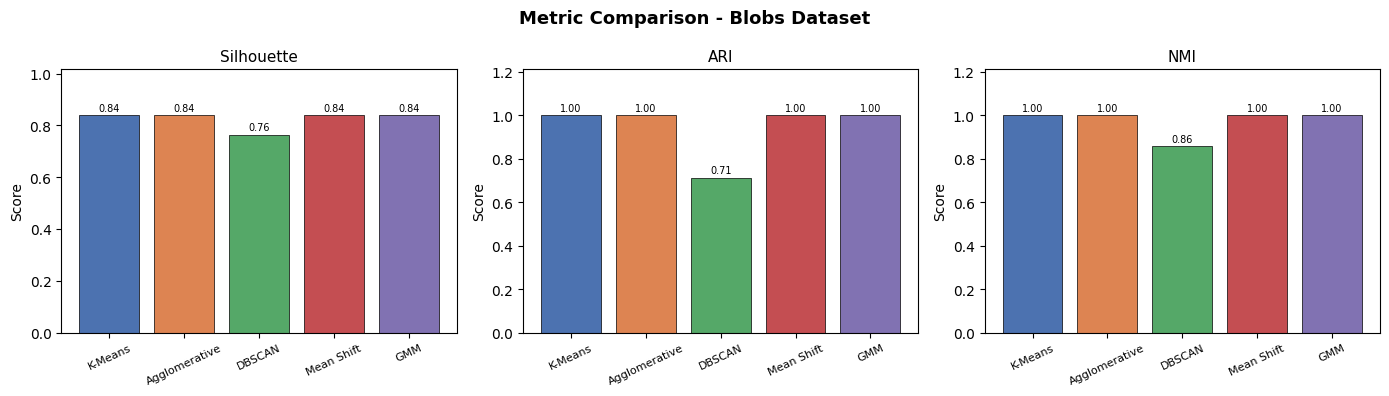

  Saved: metrics_blobs.png

Plotting Dendrogram for Iris (first 50 samples)...


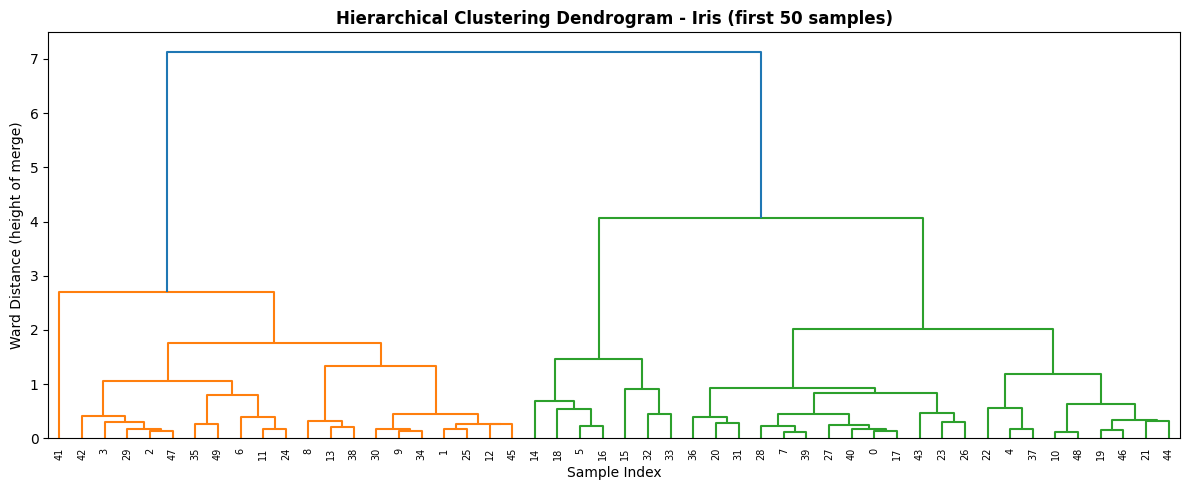

  Saved: dendrogram_iris.png

K-Means Elbow Method - Iris


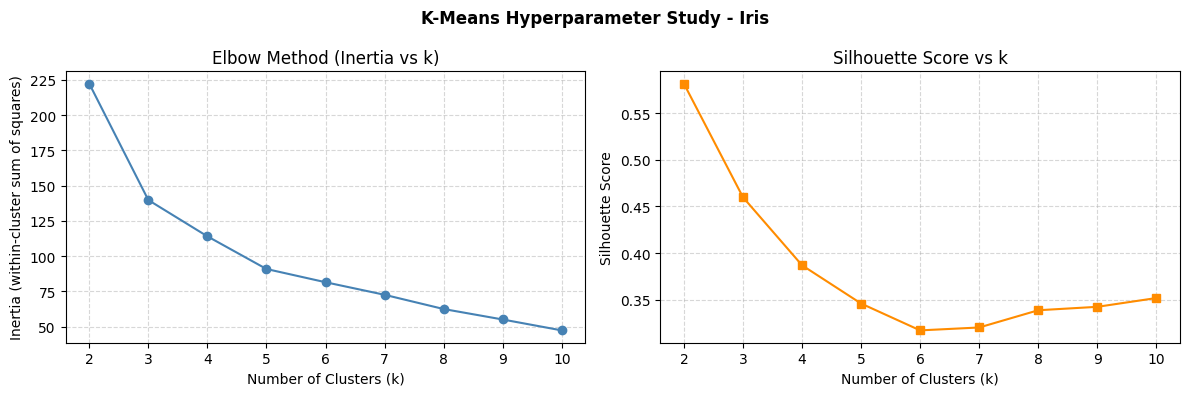

  Saved: kmeans_elbow_iris.png

DBSCAN Epsilon Study - Iris


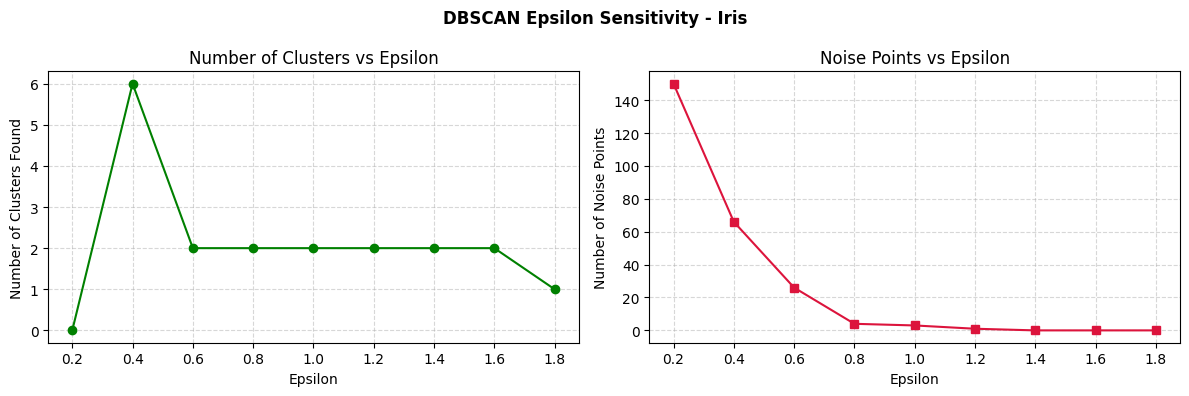

  Saved: dbscan_eps_iris.png

FINAL CROSS-DATASET SILHOUETTE COMPARISON


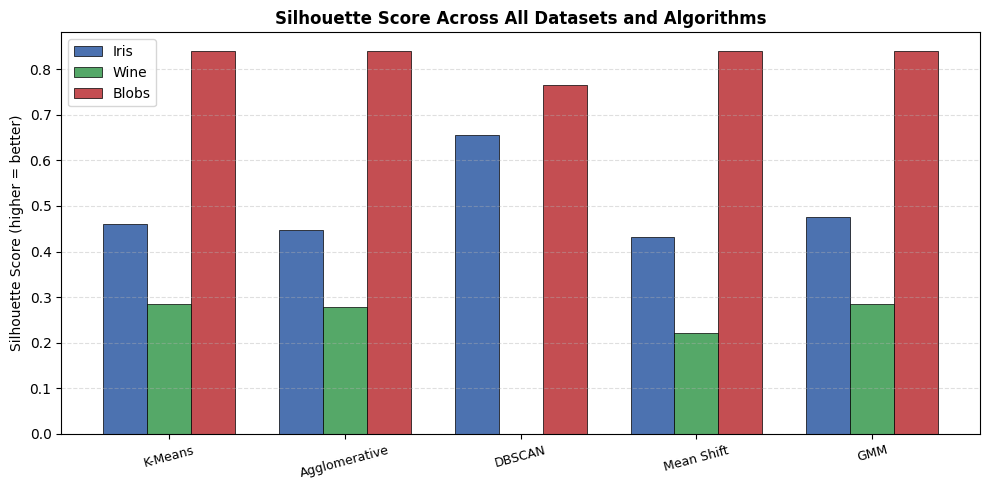

  Saved: final_comparison.png

OBSERVATIONS AND CONCLUSION

1. K-Means
   - Works best on spherical, equally-sized clusters (Blobs dataset).
   - Sensitive to the choice of k; elbow method helps select it.
   - Fails on irregular or density-varying clusters.
   - Computationally efficient: O(n * k * iterations).

2. Agglomerative Hierarchical Clustering
   - Produces a full hierarchy; no need to fix k in advance.
   - Ward linkage performs well on compact clusters (Iris, Wine).
   - The dendrogram is a useful visual tool for choosing k.
   - O(n^2) memory makes it slow for large datasets.

3. DBSCAN
   - Naturally detects noise and outliers (labeled -1).
   - Does not require specifying k.
   - Excellent on non-spherical or density-varying clusters.
   - Performance is sensitive to eps and min_samples;
     poor results on datasets with varying cluster densities.

4. Mean Shift
   - Automatically finds the number of clusters from data density.
   - No random initialization; determinist

In [1]:
# =============================================================================
# PRACTICAL 10 - Clustering Algorithms on Different Datasets
# Algorithms  : K-Means, Agglomerative, DBSCAN, Mean Shift, GMM
# Datasets    : Iris, Wine, Blobs (synthetic)
# Metrics     : Silhouette, Davies-Bouldin, Calinski-Harabasz, ARI, NMI
# =============================================================================

# --- Imports -----------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Clustering algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, MeanShift, estimate_bandwidth
from sklearn.mixture import GaussianMixture

# Evaluation metrics
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score,
                             adjusted_rand_score, normalized_mutual_info_score)

# Dendrogram for Agglomerative
from scipy.cluster.hierarchy import dendrogram, linkage

# =============================================================================
# SECTION 1 - Load and Preprocess Datasets
# =============================================================================

# --- Load Iris dataset -------------------------------------------------------
iris = datasets.load_iris()
X_iris, y_iris = iris.data, iris.target
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)          # scale to zero mean, unit variance

# --- Load Wine dataset -------------------------------------------------------
wine = datasets.load_wine()
X_wine, y_wine = wine.data, wine.target
X_wine_scaled = scaler.fit_transform(X_wine)           # wine has very different feature ranges

# --- Generate synthetic Blobs dataset ----------------------------------------
# Blobs have clear well-separated spherical clusters, good for sanity check
X_blobs, y_blobs = datasets.make_blobs(n_samples=300, centers=4,
                                        cluster_std=0.8, random_state=42)
X_blobs_scaled = scaler.fit_transform(X_blobs)

# --- Reduce to 2D with PCA for visualization ---------------------------------
# PCA does not change clustering; it is only used to plot high-dimensional data
pca = PCA(n_components=2)
X_iris_2d  = pca.fit_transform(X_iris_scaled)
X_wine_2d  = pca.fit_transform(X_wine_scaled)
X_blobs_2d = X_blobs_scaled.copy()   # blobs are already 2D after scaling

# Bundle datasets for looping
DATASETS = {
    "Iris"  : (X_iris_scaled,  X_iris_2d,  y_iris,  3),
    "Wine"  : (X_wine_scaled,  X_wine_2d,  y_wine,  3),
    "Blobs" : (X_blobs_scaled, X_blobs_2d, y_blobs, 4),
}

# =============================================================================
# SECTION 2 - Helper: Compute All Metrics for a Label Assignment
# =============================================================================

def compute_metrics(X, labels, true_labels):
    """
    Compute clustering evaluation metrics.

    Parameters
    ----------
    X           : feature matrix (scaled)
    labels      : predicted cluster labels from algorithm
    true_labels : ground truth labels (used for ARI and NMI only)

    Returns
    -------
    dict of metric name -> score (None if metric cannot be computed)
    """
    metrics = {}

    # Need at least 2 clusters present (DBSCAN may produce 1 or 0)
    n_unique = len(set(labels)) - (1 if -1 in labels else 0)

    if n_unique >= 2:
        # Exclude noise points (label == -1) from internal metrics
        mask = labels != -1
        metrics["Silhouette"]          = silhouette_score(X[mask], labels[mask])
        metrics["Davies-Bouldin"]      = davies_bouldin_score(X[mask], labels[mask])
        metrics["Calinski-Harabasz"]   = calinski_harabasz_score(X[mask], labels[mask])
    else:
        metrics["Silhouette"]          = None
        metrics["Davies-Bouldin"]      = None
        metrics["Calinski-Harabasz"]   = None

    # External metrics - compare with ground truth
    metrics["ARI"] = adjusted_rand_score(true_labels, labels)
    metrics["NMI"] = normalized_mutual_info_score(true_labels, labels)

    return metrics

# =============================================================================
# SECTION 3 - Apply All Five Clustering Algorithms
# =============================================================================

def run_all_algorithms(X, true_labels, n_clusters):
    """
    Fit K-Means, Agglomerative, DBSCAN, Mean Shift, and GMM on X.
    Return predicted labels and metrics for each algorithm.

    Parameters
    ----------
    X            : scaled feature matrix
    true_labels  : ground truth for ARI/NMI
    n_clusters   : number of clusters (used by K-Means, Agglomerative, GMM)
    """
    results = {}

    # --- 1. K-Means ----------------------------------------------------------
    # Partitions data into k spherical clusters by minimizing inertia
    # init='k-means++' picks smarter initial centroids than random
    kmeans = KMeans(n_clusters=n_clusters, init="k-means++",
                    n_init=10, random_state=42)
    km_labels = kmeans.fit_predict(X)
    results["K-Means"] = {
        "labels"  : km_labels,
        "metrics" : compute_metrics(X, km_labels, true_labels),
        "model"   : kmeans,
    }

    # --- 2. Agglomerative Hierarchical Clustering ----------------------------
    # Builds a tree (dendrogram) bottom-up by merging nearest clusters
    # ward linkage minimizes within-cluster variance at each merge
    agglo = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
    ag_labels = agglo.fit_predict(X)
    results["Agglomerative"] = {
        "labels"  : ag_labels,
        "metrics" : compute_metrics(X, ag_labels, true_labels),
        "model"   : agglo,
    }

    # --- 3. DBSCAN -----------------------------------------------------------
    # Density-based: expands clusters from dense core points
    # eps = neighborhood radius, min_samples = min points to form a core
    # Points in low-density regions are labeled -1 (noise)
    dbscan = DBSCAN(eps=0.5, min_samples=5)
    db_labels = dbscan.fit_predict(X)
    results["DBSCAN"] = {
        "labels"  : db_labels,
        "metrics" : compute_metrics(X, db_labels, true_labels),
        "model"   : dbscan,
    }

    # --- 4. Mean Shift -------------------------------------------------------
    # Finds modes (peaks) of the kernel density estimate; no k needed
    # bandwidth controls the size of the kernel window
    bw = estimate_bandwidth(X, quantile=0.2, n_samples=200, random_state=42)
    ms = MeanShift(bandwidth=bw, bin_seeding=True)
    ms_labels = ms.fit_predict(X)
    results["Mean Shift"] = {
        "labels"  : ms_labels,
        "metrics" : compute_metrics(X, ms_labels, true_labels),
        "model"   : ms,
    }

    # --- 5. Gaussian Mixture Model (GMM) ------------------------------------
    # Probabilistic model that assumes data comes from k Gaussian distributions
    # Soft assignment: each point has a probability of belonging to each cluster
    gmm = GaussianMixture(n_components=n_clusters, covariance_type="full",
                          random_state=42)
    gmm.fit(X)
    gm_labels = gmm.predict(X)
    results["GMM"] = {
        "labels"  : gm_labels,
        "metrics" : compute_metrics(X, gm_labels, true_labels),
        "model"   : gmm,
    }

    return results

# =============================================================================
# SECTION 4 - Visualization: Scatter Plots for Each Algorithm
# =============================================================================

def plot_clustering_results(X_2d, results, dataset_name):
    """
    Plot 2D scatter for each of the five algorithms side by side.
    """
    algo_names = list(results.keys())
    fig, axes = plt.subplots(1, 5, figsize=(22, 4))
    fig.suptitle(f"Clustering Results - {dataset_name} Dataset", fontsize=14, fontweight="bold")

    for ax, name in zip(axes, algo_names):
        labels = results[name]["labels"]
        unique_labels = np.unique(labels)

        # Use a colormap; noise points (-1) drawn in black
        cmap = plt.cm.get_cmap("tab10", len(unique_labels))
        for idx, lbl in enumerate(unique_labels):
            mask = labels == lbl
            color = "black" if lbl == -1 else cmap(idx)
            marker = "x" if lbl == -1 else "o"
            label_str = "Noise" if lbl == -1 else f"Cluster {lbl}"
            ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                       c=[color], marker=marker, s=20, label=label_str, alpha=0.7)

        n_found = len(unique_labels) - (1 if -1 in unique_labels else 0)
        ax.set_title(f"{name}\n({n_found} clusters found)", fontsize=10)
        ax.set_xlabel("PC1" if X_2d.shape[1] == 2 else "Feature 1")
        ax.set_ylabel("PC2" if X_2d.shape[1] == 2 else "Feature 2")
        ax.tick_params(labelsize=7)

    plt.tight_layout()
    plt.savefig(f"clustering_{dataset_name.lower()}.png", dpi=100, bbox_inches="tight")
    plt.show()
    print(f"  Saved: clustering_{dataset_name.lower()}.png")

# =============================================================================
# SECTION 5 - Visualization: Comparative Bar Charts for Metrics
# =============================================================================

def plot_metric_comparison(results, dataset_name):
    """
    Plot bar charts comparing Silhouette, ARI, and NMI across algorithms.
    Higher Silhouette = better separated clusters.
    Higher ARI/NMI = closer to ground truth.
    Lower Davies-Bouldin = better (not plotted here for clarity).
    """
    algo_names = list(results.keys())
    metrics_to_plot = ["Silhouette", "ARI", "NMI"]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(f"Metric Comparison - {dataset_name} Dataset", fontsize=13, fontweight="bold")

    colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

    for ax, metric in zip(axes, metrics_to_plot):
        values = [results[a]["metrics"].get(metric) for a in algo_names]
        # Replace None with 0 for plotting
        plot_values = [v if v is not None else 0 for v in values]

        bars = ax.bar(algo_names, plot_values, color=colors, edgecolor="black", linewidth=0.5)
        ax.set_title(metric, fontsize=11)
        ax.set_ylabel("Score")
        ax.set_ylim(0, max(plot_values) * 1.2 + 0.01)
        ax.tick_params(axis="x", rotation=25, labelsize=8)

        # Annotate bar values
        for bar, val in zip(bars, plot_values):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=7)

    plt.tight_layout()
    plt.savefig(f"metrics_{dataset_name.lower()}.png", dpi=100, bbox_inches="tight")
    plt.show()
    print(f"  Saved: metrics_{dataset_name.lower()}.png")

# =============================================================================
# SECTION 6 - Dendrogram for Agglomerative Clustering (Iris only)
# =============================================================================

def plot_dendrogram(X_scaled, dataset_name="Iris", max_display=50):
    """
    Plot the hierarchical dendrogram using ward linkage.
    The dendrogram shows how clusters are merged bottom-up.
    Cutting horizontally at a height gives a flat clustering.
    """
    print(f"\nPlotting Dendrogram for {dataset_name} (first {max_display} samples)...")
    Z = linkage(X_scaled[:max_display], method="ward")

    fig, ax = plt.subplots(figsize=(12, 5))
    dendrogram(Z, ax=ax, leaf_rotation=90, leaf_font_size=7)
    ax.set_title(f"Hierarchical Clustering Dendrogram - {dataset_name} (first {max_display} samples)",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Sample Index")
    ax.set_ylabel("Ward Distance (height of merge)")
    plt.tight_layout()
    plt.savefig(f"dendrogram_{dataset_name.lower()}.png", dpi=100, bbox_inches="tight")
    plt.show()
    print(f"  Saved: dendrogram_{dataset_name.lower()}.png")

# =============================================================================
# SECTION 7 - Hyperparameter Study
# =============================================================================

def kmeans_hyperparameter_study(X, dataset_name):
    """
    Elbow method: plot inertia vs k for K-Means.
    The 'elbow' point is the optimal k where adding more clusters gives
    diminishing returns on inertia reduction.
    """
    print(f"\nK-Means Elbow Method - {dataset_name}")
    inertia_values = []
    silhouette_values = []
    k_range = range(2, 11)

    for k in k_range:
        km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
        labels = km.fit_predict(X)
        inertia_values.append(km.inertia_)
        silhouette_values.append(silhouette_score(X, labels))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"K-Means Hyperparameter Study - {dataset_name}", fontsize=12, fontweight="bold")

    axes[0].plot(k_range, inertia_values, marker="o", color="steelblue")
    axes[0].set_title("Elbow Method (Inertia vs k)")
    axes[0].set_xlabel("Number of Clusters (k)")
    axes[0].set_ylabel("Inertia (within-cluster sum of squares)")
    axes[0].grid(True, linestyle="--", alpha=0.5)

    axes[1].plot(k_range, silhouette_values, marker="s", color="darkorange")
    axes[1].set_title("Silhouette Score vs k")
    axes[1].set_xlabel("Number of Clusters (k)")
    axes[1].set_ylabel("Silhouette Score")
    axes[1].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.savefig(f"kmeans_elbow_{dataset_name.lower()}.png", dpi=100, bbox_inches="tight")
    plt.show()
    print(f"  Saved: kmeans_elbow_{dataset_name.lower()}.png")


def dbscan_hyperparameter_study(X, dataset_name):
    """
    Study how DBSCAN's eps parameter affects the number of clusters and noise.
    Small eps = many noise points, large eps = everything merged into one cluster.
    """
    print(f"\nDBSCAN Epsilon Study - {dataset_name}")
    eps_values = np.arange(0.2, 2.0, 0.2)
    n_clusters_list = []
    n_noise_list = []

    for eps in eps_values:
        db = DBSCAN(eps=eps, min_samples=5)
        labels = db.fit_predict(X)
        n_clusters_list.append(len(set(labels)) - (1 if -1 in labels else 0))
        n_noise_list.append(np.sum(labels == -1))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"DBSCAN Epsilon Sensitivity - {dataset_name}", fontsize=12, fontweight="bold")

    axes[0].plot(eps_values, n_clusters_list, marker="o", color="green")
    axes[0].set_title("Number of Clusters vs Epsilon")
    axes[0].set_xlabel("Epsilon")
    axes[0].set_ylabel("Number of Clusters Found")
    axes[0].grid(True, linestyle="--", alpha=0.5)

    axes[1].plot(eps_values, n_noise_list, marker="s", color="crimson")
    axes[1].set_title("Noise Points vs Epsilon")
    axes[1].set_xlabel("Epsilon")
    axes[1].set_ylabel("Number of Noise Points")
    axes[1].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.savefig(f"dbscan_eps_{dataset_name.lower()}.png", dpi=100, bbox_inches="tight")
    plt.show()
    print(f"  Saved: dbscan_eps_{dataset_name.lower()}.png")

# =============================================================================
# SECTION 8 - Print Summary Table of All Metrics
# =============================================================================

def print_metrics_table(results, dataset_name):
    """
    Print a readable table of all metrics for every algorithm.
    """
    print(f"\n{'='*70}")
    print(f"  METRICS SUMMARY  -  {dataset_name} Dataset")
    print(f"{'='*70}")
    header = f"{'Algorithm':<20} {'Silhouette':>12} {'DB-Index':>10} {'CH-Index':>12} {'ARI':>8} {'NMI':>8}"
    print(header)
    print("-" * 70)

    for algo, data in results.items():
        m = data["metrics"]
        sil = f"{m['Silhouette']:.4f}" if m["Silhouette"] is not None else "  N/A  "
        db  = f"{m['Davies-Bouldin']:.4f}" if m["Davies-Bouldin"] is not None else "  N/A  "
        ch  = f"{m['Calinski-Harabasz']:.2f}" if m["Calinski-Harabasz"] is not None else "  N/A  "
        ari = f"{m['ARI']:.4f}"
        nmi = f"{m['NMI']:.4f}"
        n_clust = len(set(data["labels"])) - (1 if -1 in data["labels"] else 0)
        print(f"{algo:<20} {sil:>12} {db:>10} {ch:>12} {ari:>8} {nmi:>8}  (k={n_clust})")

    print("="*70)
    print("  Lower Davies-Bouldin is better.")
    print("  Higher Silhouette, CH-Index, ARI, NMI are better.")
    print()

# =============================================================================
# SECTION 9 - MAIN EXECUTION: Run Everything
# =============================================================================

all_results = {}    # store results per dataset for later comparison

for ds_name, (X_sc, X_2d, y_true, n_clust) in DATASETS.items():

    print(f"\n{'#'*70}")
    print(f"  DATASET: {ds_name}  |  Shape: {X_sc.shape}  |  True clusters: {n_clust}")
    print(f"{'#'*70}")

    # --- Run all five algorithms ---
    results = run_all_algorithms(X_sc, y_true, n_clust)
    all_results[ds_name] = results

    # --- Print metrics table ---
    print_metrics_table(results, ds_name)

    # --- Scatter plots of cluster assignments ---
    plot_clustering_results(X_2d, results, ds_name)

    # --- Bar charts comparing metrics ---
    plot_metric_comparison(results, ds_name)

# =============================================================================
# SECTION 10 - Dendrogram (Iris dataset example)
# =============================================================================

plot_dendrogram(X_iris_scaled, dataset_name="Iris", max_display=50)

# =============================================================================
# SECTION 11 - Hyperparameter Studies (Iris dataset example)
# =============================================================================

kmeans_hyperparameter_study(X_iris_scaled, dataset_name="Iris")
dbscan_hyperparameter_study(X_iris_scaled, dataset_name="Iris")

# =============================================================================
# SECTION 12 - Final Cross-Dataset Comparison (Silhouette Score)
# =============================================================================

print("\nFINAL CROSS-DATASET SILHOUETTE COMPARISON")
algo_names = list(all_results["Iris"].keys())
dataset_names = list(all_results.keys())

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(algo_names))
width = 0.25
colors_ds = ["#4C72B0", "#55A868", "#C44E52"]

for i, (ds, color) in enumerate(zip(dataset_names, colors_ds)):
    vals = [all_results[ds][a]["metrics"]["Silhouette"] or 0 for a in algo_names]
    ax.bar(x + i * width, vals, width, label=ds, color=color, edgecolor="black", linewidth=0.5)

ax.set_title("Silhouette Score Across All Datasets and Algorithms", fontsize=12, fontweight="bold")
ax.set_ylabel("Silhouette Score (higher = better)")
ax.set_xticks(x + width)
ax.set_xticklabels(algo_names, rotation=15, fontsize=9)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("final_comparison.png", dpi=100, bbox_inches="tight")
plt.show()
print("  Saved: final_comparison.png")

# =============================================================================
# SECTION 13 - Observations and Conclusion (printed to output)
# =============================================================================

print("""
OBSERVATIONS AND CONCLUSION
============================

1. K-Means
   - Works best on spherical, equally-sized clusters (Blobs dataset).
   - Sensitive to the choice of k; elbow method helps select it.
   - Fails on irregular or density-varying clusters.
   - Computationally efficient: O(n * k * iterations).

2. Agglomerative Hierarchical Clustering
   - Produces a full hierarchy; no need to fix k in advance.
   - Ward linkage performs well on compact clusters (Iris, Wine).
   - The dendrogram is a useful visual tool for choosing k.
   - O(n^2) memory makes it slow for large datasets.

3. DBSCAN
   - Naturally detects noise and outliers (labeled -1).
   - Does not require specifying k.
   - Excellent on non-spherical or density-varying clusters.
   - Performance is sensitive to eps and min_samples;
     poor results on datasets with varying cluster densities.

4. Mean Shift
   - Automatically finds the number of clusters from data density.
   - No random initialization; deterministic.
   - Slow on large datasets (O(n^2)); bandwidth estimation is critical.
   - Tends to over-segment on high-dimensional data.

5. Gaussian Mixture Models (GMM)
   - Soft probabilistic assignments allow for elliptical clusters.
   - Often outperforms K-Means on datasets with overlapping clusters (Iris, Wine).
   - Requires specifying number of components.
   - More flexible than K-Means due to full covariance estimation.

Best Algorithm per Dataset
   - Iris  : GMM or Agglomerative (overlapping classes in PCA space)
   - Wine  : K-Means or GMM (well-separated after scaling)
   - Blobs : K-Means (ideal spherical clusters; highest scores on all metrics)

Overall: No single algorithm dominates all datasets. The best choice depends
on cluster shape, density, noise level, and whether k is known in advance.
""")

In [4]:
import os

OUTPUT_DIR = "clustering_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [5]:
def plot(X, res, name):
    fig, ax = plt.subplots(1, 5, figsize=(18, 4))
    fig.suptitle(name)

    for i, (algo, (labels, _)) in enumerate(res.items()):
        ax[i].scatter(X[:, 0], X[:, 1], c=labels, s=10)
        ax[i].set_title(algo)

    filename = os.path.join(OUTPUT_DIR, f"{name}_clusters.png")
    plt.savefig(filename, dpi=100, bbox_inches="tight")
    plt.show()

    print(f"Saved: {filename}")

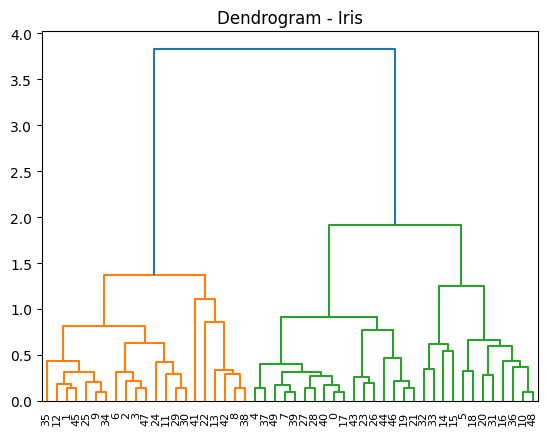

Saved: clustering_outputs\iris_dendrogram.png


In [6]:
Z = linkage(X_iris[:50], method='ward')
plt.figure()
dendrogram(Z)
plt.title("Dendrogram - Iris")

file_path = os.path.join(OUTPUT_DIR, "iris_dendrogram.png")
plt.savefig(file_path, dpi=100, bbox_inches="tight")
plt.show()

print(f"Saved: {file_path}")